# Experiment 4: Cross-Lingual Aesthetic Universality

**Research Question**: Do aesthetic representations in different languages occupy the same region in activation space? Is the English-trained aesthetic direction a **universal beauty detector** that works for Chinese, Japanese, French, and Spanish?

## Motivation
Experiments 2–3 mapped the aesthetic subspace and its emergence using English prompts. But Qwen3-8B is a multilingual model. If the aesthetic direction is truly capturing the *concept* of beauty, it should transfer across languages. If it only captures English poetic vocabulary, it will fail on other languages.

## Method
1. **Multilingual sentence dataset** — 15 beautiful + 15 plain/ugly in each of 5 languages (EN, ZH, JA, FR, ES)
2. **Zero-shot cross-lingual transfer** — Project all sentences onto Exp 2's English aesthetic direction → classify
3. **Per-language aesthetic directions** — Compute language-specific directions, measure pairwise cosine similarity
4. **PCA visualization** — Color by language and by aesthetic label → cluster by beauty or by language?
5. **Linear probe transfer** — Train on English, test on each other language

## 1. Setup & Environment

In [1]:
import neuroscope
import numpy as np
import sys, os, time, warnings
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from scipy import stats

# --- Matplotlib CJK font config ---
_cjk_font_dir = '/usr/share/fonts/opentype/noto/'
for _fp in fm.findSystemFonts([_cjk_font_dir]):
    fm.fontManager.addfont(_fp)
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

sys.path.insert(0, '/workspace/Test_bench')
import utils

os.environ['GGML_CUDA_DISABLE_GRAPHS'] = '1'
os.environ['HF_HOME'] = '/workspace/Data/huggingface_cache'
os.environ['TORCH_HOME'] = '/workspace/Data/torch_cache'

warnings.filterwarnings('ignore')
print(f'NeuroScope {neuroscope.__version__}, CUDA: {neuroscope.cuda_available()}')

NeuroScope 1.2.3, CUDA: True


In [2]:
# --- Config ---
MODEL_PATH = '/workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf'
OUTPUT_DIR = Path('/workspace/Data/cross_lingual_aesthetics')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Experiment 2 results (English aesthetic direction)
EXP2_DIR = Path('/workspace/Data/aesthetic_experiment')
EXP3_DIR = Path('/workspace/Data/aesthetic_emergence')

NOTHINK_SUFFIX = '<think>\n\n</think>\n\n'
SEED = 42
np.random.seed(SEED)

LANGUAGES = ['EN', 'ZH', 'JA', 'FR', 'ES']
LANG_NAMES = {'EN': 'English', 'ZH': '中文 (Chinese)', 'JA': '日本語 (Japanese)',
              'FR': 'Français (French)', 'ES': 'Español (Spanish)'}
LANG_COLORS = {'EN': '#1f77b4', 'ZH': '#d62728', 'JA': '#2ca02c', 'FR': '#9467bd', 'ES': '#ff7f0e'}

print(f'Output: {OUTPUT_DIR}')
print(f'Languages: {LANGUAGES}')

Output: /workspace/Data/cross_lingual_aesthetics
Languages: ['EN', 'ZH', 'JA', 'FR', 'ES']


## 2. Load Engine & Exp 2 Aesthetic Direction

In [3]:
engine = neuroscope.Engine(
    model_path=MODEL_PATH,
    n_ctx=4096,
    n_gpu_layers=-1,
    n_seq_max=1,
    seed=SEED,
    temperature=0.7,
    top_p=0.95,
    top_k=40,
    verbose=True
)

info = engine.model_info
N_LAYERS = info.n_layers
N_EMBD   = info.n_embd
N_VOCAB  = info.n_vocab
print(f'Model: {info.name}')
print(f'Layers: {N_LAYERS} | Hidden: {N_EMBD} | Vocab: {N_VOCAB}')

# Load Exp 2 English aesthetic direction
exp2_data = np.load(EXP2_DIR / 'aesthetic_analysis_results.npz', allow_pickle=True)
aesthetic_direction = exp2_data['aesthetic_direction']       # (36, 4096) unnormalized
aesthetic_direction_norm = exp2_data['aesthetic_direction_norm']  # (36, 4096) L2-normed
best_layer = int(exp2_data['best_cls_layer'])

print(f'\nExp 2 aesthetic direction loaded: shape={aesthetic_direction.shape}')
print(f'Best classification layer (Exp 2): {best_layer}')
print(f'Direction L2 norms: L0={np.linalg.norm(aesthetic_direction[0]):.2f}, '
      f'L{best_layer}={np.linalg.norm(aesthetic_direction[best_layer]):.2f}, '
      f'L{N_LAYERS-1}={np.linalg.norm(aesthetic_direction[N_LAYERS-1]):.2f}')

Model: Qwen3 8B Awq Compatible Instruct[CoreEngine] Loading model: /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf

Layers: 36 | Hidden: 4096 | Vocab: 151936
[CoreEngine] Preparing logit lens resources:
  - Tensor shape: [151936, 4096]
  - Tensor type: q6_K
  - Quantized weights (q6_K) dequantized to FP16
  - FP16 weights allocated on GPU: 1187 MB
  - Logit lens ready for all model types!
[CoreEngine] Model loaded: Qwen3 8B Awq Compatible Instruct
  Architecture: qwen (qwen3)
  Layers: 36, Hidden: 4096
  Heads: 32 Q, 8 KV (GQA)

Exp 2 aesthetic direction loaded: shape=(36, 4096)
Best classification layer (Exp 2): 16
Direction L2 norms: L0=0.29, L16=7.22, L35=202.13


ggml_cuda_init: found 1 CUDA devices:
  Device 0: NVIDIA GB10, compute capability 12.1, VMM: yes
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 93439692
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 93439692
llama_model_load_from_file_impl: using device CUDA0 (NVIDIA GB10) (000f:01:00.0) - 91249 MiB free
llama_model_loader: loaded meta data with 28 key-value pairs and 399 tensors from /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen3 8B Awq Compatible Instruct
llama_model_loader: - kv   3:                           general.f

## 3. Multilingual Aesthetic Sentence Dataset

15 beautiful + 15 plain/ugly per language. Sentences are original (not translations) to capture each language's natural aesthetic register. Controlled for similar length and topic diversity (nature, art, architecture, sensory, literary).

In [4]:
# ============================================================
# Multilingual Aesthetic Sentence Dataset
# Each language: 15 beautiful (label=1), 15 plain/ugly (label=0)
# ============================================================

SENTENCES = {
    'EN': {
        'beautiful': [
            "The morning dew glistened on the spider's web like scattered diamonds.",
            "A cascade of cherry blossoms drifted through the still spring air.",
            "The sunset painted the clouds in shades of gold and violet.",
            "Moonlight rippled across the lake like liquid silver.",
            "The cellist drew a melody so tender it made the silence ache.",
            "The cathedral's stained glass scattered rainbows across the stone floor.",
            "Her laughter was the sound of sunlight breaking through winter clouds.",
            "The tea released a fragrance of jasmine and mountain mist.",
            "Frost etched delicate fern patterns across the windowpane at dawn.",
            "The piano notes cascaded like rain on a still autumn pond.",
            "Light poured through the oculus, illuminating the dome's golden mosaic.",
            "The dancers moved as one, a flowing river of silk and shadow.",
            "The wine held notes of blackberry, cedar, and a hint of autumn smoke.",
            "Wildflowers swayed in the meadow, a tapestry of color under the summer sun.",
            "The marble sculpture captured a moment of impossible grace.",
        ],
        'plain_ugly': [
            "The office building had twelve floors and a flat concrete roof.",
            "The spreadsheet contained rows of quarterly sales figures from last year.",
            "The parking lot was half empty with oil stains on the asphalt.",
            "Garbage bags split open in the alley, spilling rotting food scraps.",
            "The stagnant ditch water was thick with algae and mosquito larvae.",
            "The database index was rebuilt after the scheduled maintenance window.",
            "The thermostat was set to twenty-two degrees Celsius year-round.",
            "The room had a table, four chairs, and a window facing the street.",
            "The cafeteria food tasted of reheated cardboard and stale grease.",
            "Rust had eaten through the metal railing, leaving jagged orange edges.",
            "The fluorescent lights hummed steadily in the windowless break room.",
            "Dead flies lined the windowsill of the vacant apartment.",
            "The concrete mix ratio was one part cement to three parts aggregate.",
            "The vending machine dispensed a can of cola for one dollar fifty.",
            "The overcooked vegetables had turned to a grey, mushy paste.",
        ]
    },
    'ZH': {
        'beautiful': [
            "晨雾缭绕在山间，远处传来寺庙的钟声，悠远而空灵。",
            "一树梨花开在月光下，花瓣上凝着晶莹的露珠。",
            "落日余晖将江面染成一片金红，渔舟唱晚，归鸥翩然。",
            "竹林深处传来古琴声，如泉水叮咚，清冽透明。",
            "青石板路上，细雨如丝，油纸伞下是一缕淡淡的桂花香。",
            "雪后初晴，红梅独自绽放在白雪皑皑的庭院中。",
            "西湖的荷花在晨光中舒展，露珠在碧绿的叶片上滚动。",
            "月下的古桥倒映在水面，像一幅泼墨山水画。",
            "茶烟袅袅升起，紫砂壶中的龙井散发着淡雅的清香。",
            "丝竹之声婉转悠扬，如春风拂过柳枝。",
            "飞檐翘角的亭台掩映在翠竹碧水之间，如诗如画。",
            "秋天的银杏大道铺满金黄色的落叶，宛如黄金地毯。",
            "老宅院里的月季开得正盛，花香弥漫了整个黄昏。",
            "远山如黛，近水含烟，一叶扁舟悠然于天地之间。",
            "琵琶声声，诉说着千年前的离愁别绪。",
        ],
        'plain_ugly': [
            "这栋办公楼有六层，外墙贴着白色瓷砖。",
            "会议记录显示本季度销售额同比下降百分之三。",
            "停车场里积了一滩浑浊的雨水，上面漂着烟头。",
            "垃圾箱已经满了，果皮和塑料袋散落在地上。",
            "下水道堵了，污水从井盖缝隙中渗出来。",
            "仓库里整齐地摆放着一排排金属货架。",
            "空调设定温度为二十五度，运转正常。",
            "食堂的饭菜味道很一般，米饭有点硬。",
            "生锈的铁门发出刺耳的嘎吱声。",
            "走廊的日光灯管闪烁不定，发出嗡嗡的声响。",
            "工地上到处是泥浆和碎砖头，灰尘漫天。",
            "报表需要在每月十五号之前提交给财务部门。",
            "水泥地面上有几道裂缝，边角处长了青苔。",
            "方便面泡了太久，面条已经变成了一团糊状物。",
            "厕所的排风扇噪音很大，异味始终挥之不去。",
        ]
    },
    'JA': {
        'beautiful': [
            "朝露に濡れた蜘蛛の巣が、朝日を受けて宝石のように輝いている。",
            "桜吹雪が静かな庭に舞い降り、石灯籠を薄紅色に染めた。",
            "夕暮れの富士山が、湖面に完璧な逆さ富士を映し出していた。",
            "古寺の鐘の音が、霧に包まれた山間に静かに響き渡った。",
            "枯山水の白砂に描かれた波紋が、無限の海を思わせる。",
            "金継ぎで修復された茶碗は、傷をまとって一層美しくなった。",
            "紅葉が渓谷を燃えるように彩り、清流に赤い葉が漂う。",
            "三味線の音色が夜の花街に響き、儚い風情を醸し出す。",
            "苔むした石段を登ると、木漏れ日が緑の光の粒になって降り注ぐ。",
            "雪の中に咲く椿の赤が、静寂の中でひときわ鮮やかだった。",
            "障子に映る竹の影が、風に揺れて水墨画のようだった。",
            "抹茶の鮮やかな緑が白い茶碗に映え、ほのかな苦みが心を落ち着かせる。",
            "月明かりの下、白藤が滝のように垂れ下がり、甘い香りが漂う。",
            "尺八の音が竹林に溶け込み、風の声と一つになった。",
            "朝霧の中から現れた鶴の群れが、銀色の翼を広げて飛び立った。",
        ],
        'plain_ugly': [
            "このビルは築三十年で、外壁のタイルが所々剥がれている。",
            "月次報告書の提出期限は毎月二十日です。",
            "駐車場のアスファルトにひびが入り、雑草が生えている。",
            "生ごみの袋が破れて、悪臭が廊下に漂っていた。",
            "排水溝が詰まって、灰色の汚水が溜まっている。",
            "倉庫内の棚には段ボール箱が整然と並んでいる。",
            "エアコンの設定温度は二十六度で、フィルター清掃は月一回です。",
            "社員食堂のカレーは具が少なく、味が薄かった。",
            "錆びた非常階段がきしむ音を立てた。",
            "蛍光灯がちらちら点滅して、目が疲れる。",
            "工事現場は泥だらけで、騒音が絶え間なく続いていた。",
            "請求書の処理は経理部の承認が必要です。",
            "コンクリートの壁にカビが黒く広がっている。",
            "カップ麺を放置しすぎて、麺がふやけてどろどろになった。",
            "トイレの換気扇が壊れていて、嫌な臭いが充満している。",
        ]
    },
    'FR': {
        'beautiful': [
            "La rosée du matin scintillait sur les pétales comme des perles de lumière.",
            "Les cerisiers en fleurs bordaient l'allée d'un voile rose et parfumé.",
            "Le soleil couchant embrasait la mer d'or et de pourpre.",
            "Le clair de lune caressait les toits de Paris d'une lueur argentée.",
            "Le violoncelle pleurait une mélodie qui faisait frémir l'âme.",
            "Les vitraux de la cathédrale projetaient des arcs-en-ciel sur la pierre ancienne.",
            "Son rire résonnait comme une cascade de cristal dans le jardin.",
            "Le thé au jasmin exhalait un parfum délicat et envoûtant.",
            "Le givre dessinait des arabesques de dentelle sur les carreaux.",
            "Les notes du piano s'égrainaient comme une pluie fine sur un étang.",
            "La lumière filtrait à travers la voûte, illuminant les fresques dorées.",
            "Les danseurs glissaient sur la scène, légers comme des feuilles d'automne.",
            "Ce vin révélait des notes de cassis, de cèdre et de fumée d'automne.",
            "Les lavandes ondulaient sous la brise, un océan violet sous le ciel bleu.",
            "La sculpture de marbre semblait respirer, figée dans une grâce éternelle.",
        ],
        'plain_ugly': [
            "L'immeuble de bureaux comptait douze étages et un toit plat en béton.",
            "Le tableau Excel contenait les chiffres de ventes du trimestre passé.",
            "Le parking était à moitié vide avec des taches d'huile sur le bitume.",
            "Les sacs-poubelle éventrés répandaient des déchets dans la ruelle.",
            "L'eau stagnante du fossé était verdâtre et sentait le moisi.",
            "La base de données a été réindexée après la maintenance prévue.",
            "Le thermostat était réglé à vingt-deux degrés toute l'année.",
            "La pièce contenait une table, quatre chaises et une fenêtre sur rue.",
            "La nourriture de la cantine avait un goût de carton réchauffé.",
            "La rouille avait rongé la rampe métallique, laissant des bords dentelés.",
            "Les néons bourdonnaient dans la salle de pause sans fenêtre.",
            "Des mouches mortes s'alignaient sur le rebord de la fenêtre.",
            "Le dosage du béton était d'une part de ciment pour trois de granulats.",
            "Le distributeur délivrait une canette de cola pour un euro cinquante.",
            "Les légumes trop cuits s'étaient transformés en bouillie grisâtre.",
        ]
    },
    'ES': {
        'beautiful': [
            "El rocío de la mañana brillaba en la tela de araña como diamantes esparcidos.",
            "Los cerezos en flor cubrían el sendero con un manto rosa y fragante.",
            "El atardecer incendió el horizonte en tonos de oro y violeta.",
            "La luz de la luna se derramaba sobre el lago como plata líquida.",
            "El violonchelo tejía una melodía tan tierna que el silencio se estremecía.",
            "Los vitrales de la catedral esparcían arcoíris sobre el suelo de piedra.",
            "Su risa era como el sonido del agua cristalina sobre las piedras del río.",
            "El té de jazmín desprendía un perfume delicado y envolvente.",
            "La escarcha dibujó encajes de cristal sobre los vidrios al amanecer.",
            "Las notas del piano caían como lluvia suave sobre un estanque en calma.",
            "La luz entraba por la cúpula, iluminando los mosaicos dorados.",
            "Los bailarines se movían como uno solo, un río de seda y sombra.",
            "El vino guardaba notas de mora, cedro y un toque de humo otoñal.",
            "Los campos de lavanda ondulaban bajo la brisa como un mar violeta.",
            "La escultura de mármol capturaba un instante de gracia imposible.",
        ],
        'plain_ugly': [
            "El edificio de oficinas tenía doce pisos y un techo plano de hormigón.",
            "La hoja de cálculo contenía las cifras de ventas del trimestre pasado.",
            "El estacionamiento estaba medio vacío con manchas de aceite en el asfalto.",
            "Las bolsas de basura reventadas derramaban desperdicios en el callejón.",
            "El agua estancada de la zanja estaba turbia y llena de larvas.",
            "El índice de la base de datos se reconstruyó tras el mantenimiento.",
            "El termostato estaba fijado a veintidós grados todo el año.",
            "La habitación tenía una mesa, cuatro sillas y una ventana a la calle.",
            "La comida de la cafetería sabía a cartón recalentado y grasa rancia.",
            "El óxido había comido la barandilla dejando bordes afilados y anaranjados.",
            "Las luces fluorescentes zumbaban en la sala de descanso sin ventanas.",
            "Moscas muertas se alineaban en el alféizar del apartamento vacío.",
            "La mezcla de hormigón era una parte de cemento por tres de áridos.",
            "La máquina expendedora dispensaba una lata de cola por un euro cincuenta.",
            "Las verduras cocidas de más se habían convertido en pasta grisácea.",
        ]
    },
}

# Verify dataset
for lang in LANGUAGES:
    nb = len(SENTENCES[lang]['beautiful'])
    nu = len(SENTENCES[lang]['plain_ugly'])
    print(f'{lang}: {nb} beautiful + {nu} plain/ugly = {nb+nu} total')
    assert nb == 15 and nu == 15, f'{lang} has wrong count!'

N_PER_LANG = 30  # 15+15
N_BEAUTIFUL = 15
N_TOTAL = N_PER_LANG * len(LANGUAGES)
print(f'\nTotal: {N_TOTAL} sentences across {len(LANGUAGES)} languages')

EN: 15 beautiful + 15 plain/ugly = 30 total
ZH: 15 beautiful + 15 plain/ugly = 30 total
JA: 15 beautiful + 15 plain/ugly = 30 total
FR: 15 beautiful + 15 plain/ugly = 30 total
ES: 15 beautiful + 15 plain/ugly = 30 total

Total: 150 sentences across 5 languages


## 4. Collect Activations (All Languages)

In [5]:
def collect_activations(engine, sentences):
    """Collect all-layer last-token activations for a list of sentences.
    Returns: np.ndarray of shape (n_sentences, n_layers, n_embd)
    """
    all_acts = []
    for sent in sentences:
        messages = [{'role': 'user', 'content': sent}]
        templated = engine.apply_chat_template(messages) + NOTHINK_SUFFIX
        engine.reset()
        engine.forward(templated, add_special=True)
        acts = engine.get_all_activations()  # list of [n_embd] per layer
        all_acts.append(np.array(acts))      # (n_layers, n_embd)
    return np.array(all_acts)  # (n_sentences, n_layers, n_embd)

# Collect activations for all languages
activations = {}   # lang -> (30, 36, 4096)
labels = {}        # lang -> (30,) binary

t_start = time.time()
for lang in LANGUAGES:
    sents = SENTENCES[lang]['beautiful'] + SENTENCES[lang]['plain_ugly']
    labs = np.array([1]*N_BEAUTIFUL + [0]*N_BEAUTIFUL)
    
    print(f'Collecting {lang}...', end=' ', flush=True)
    t0 = time.time()
    activations[lang] = collect_activations(engine, sents)
    labels[lang] = labs
    print(f'{activations[lang].shape} in {time.time()-t0:.1f}s')

print(f'\nTotal collection time: {time.time()-t_start:.1f}s')

# Save raw activations
np.savez_compressed(OUTPUT_DIR / 'multilingual_activations.npz',
    **{f'acts_{lang}': activations[lang] for lang in LANGUAGES},
    **{f'labels_{lang}': labels[lang] for lang in LANGUAGES})
fsize = (OUTPUT_DIR / 'multilingual_activations.npz').stat().st_size / 1e6
print(f'Saved: {fsize:.1f} MB')


Total collection time: 7.0s
Saved: 82.1 MB


## 5. Zero-Shot Cross-Lingual Transfer

Project all non-English sentences onto the **English aesthetic direction** (from Exp 2). If the direction is universal, it should separate beautiful from ugly in all languages without any retraining.

In [6]:
# Project each sentence onto the aesthetic direction at each layer
# Score = dot(activation, aesthetic_direction_norm)
# Positive = aesthetic, Negative = anti-aesthetic

projections = {}  # lang -> (30, 36) projection scores
for lang in LANGUAGES:
    proj = np.zeros((N_PER_LANG, N_LAYERS))
    for i in range(N_PER_LANG):
        for layer in range(N_LAYERS):
            proj[i, layer] = np.dot(activations[lang][i, layer], aesthetic_direction_norm[layer])
    projections[lang] = proj

# Compute AUC at each layer for each language using the projection score
layers = np.arange(N_LAYERS)
transfer_auc = {}  # lang -> (36,) AUC at each layer

print(f'{"Layer":>5}', end='')
for lang in LANGUAGES:
    print(f' | {lang:>6}', end='')
print()
print('-' * (5 + 9 * len(LANGUAGES)))

for lang in LANGUAGES:
    aucs = []
    for layer in range(N_LAYERS):
        auc = roc_auc_score(labels[lang], projections[lang][:, layer])
        aucs.append(auc)
    transfer_auc[lang] = np.array(aucs)

# Print table every 4 layers
for layer in range(0, N_LAYERS, 4):
    print(f'{layer:>5}', end='')
    for lang in LANGUAGES:
        print(f' | {transfer_auc[lang][layer]:>6.3f}', end='')
    print()

# Best layer per language
print(f'\n{"Best":>5}', end='')
for lang in LANGUAGES:
    best_l = np.argmax(transfer_auc[lang])
    print(f' | L{best_l}={transfer_auc[lang][best_l]:.3f}', end='')
print()

Layer |     EN |     ZH |     JA |     FR |     ES
--------------------------------------------------
    0 |  0.849 |  1.000 |  1.000 |  0.649 |  0.764
    4 |  0.987 |  1.000 |  1.000 |  0.849 |  0.929
    8 |  0.991 |  1.000 |  1.000 |  0.969 |  1.000
   12 |  1.000 |  1.000 |  1.000 |  0.991 |  1.000
   16 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000
   20 |  0.996 |  1.000 |  1.000 |  1.000 |  1.000
   24 |  1.000 |  1.000 |  0.996 |  0.978 |  1.000
   28 |  1.000 |  1.000 |  0.996 |  0.982 |  1.000
   32 |  1.000 |  1.000 |  0.996 |  0.978 |  1.000

 Best | L12=1.000 | L0=1.000 | L0=1.000 | L15=1.000 | L7=1.000


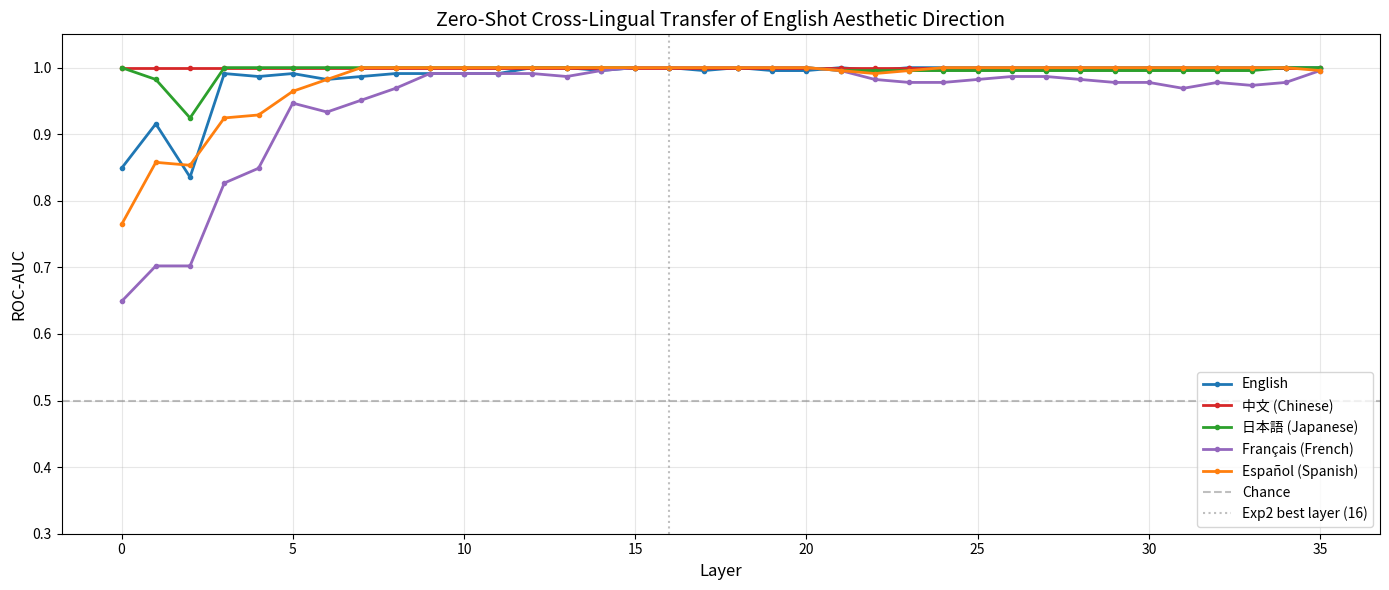


Zero-shot transfer AUC at Exp2 best layer (L16):

  English             : AUC = 1.000  ✓ Perfect
  中文 (Chinese)        : AUC = 1.000  ✓ Perfect
  日本語 (Japanese)      : AUC = 1.000  ✓ Perfect
  Français (French)   : AUC = 1.000  ✓ Perfect
  Español (Spanish)   : AUC = 1.000  ✓ Perfect


In [7]:
# --- Plot: Zero-shot cross-lingual transfer AUC ---
fig, ax = plt.subplots(figsize=(14, 6))

for lang in LANGUAGES:
    ax.plot(layers, transfer_auc[lang], 'o-', color=LANG_COLORS[lang],
            label=f'{LANG_NAMES[lang]}', markersize=3, linewidth=2)

ax.axhline(0.5, color='gray', ls='--', alpha=0.5, label='Chance')
ax.axvline(best_layer, color='gray', ls=':', alpha=0.5, label=f'Exp2 best layer ({best_layer})')
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('Zero-Shot Cross-Lingual Transfer of English Aesthetic Direction', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0.3, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_lingual_transfer_auc.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('\nZero-shot transfer AUC at Exp2 best layer (L{}):\n'.format(best_layer))
for lang in LANGUAGES:
    auc = transfer_auc[lang][best_layer]
    status = '✓ Perfect' if auc >= 0.999 else ('✓ Excellent' if auc >= 0.95 else ('~ Good' if auc >= 0.85 else '✗ Weak'))
    print(f'  {LANG_NAMES[lang]:20s}: AUC = {auc:.3f}  {status}')

## 6. Per-Language Aesthetic Directions

Compute the aesthetic direction independently for each language and measure **pairwise cosine similarity**. If all languages share the same direction, the similarity should be high.

In [8]:
# Compute per-language aesthetic directions at each layer
# direction = mean(beautiful_acts) - mean(ugly_acts)

lang_directions = {}  # lang -> (36, 4096)
for lang in LANGUAGES:
    acts = activations[lang]  # (30, 36, 4096)
    beautiful_mean = acts[:N_BEAUTIFUL].mean(axis=0)   # (36, 4096)
    ugly_mean = acts[N_BEAUTIFUL:].mean(axis=0)        # (36, 4096)
    lang_directions[lang] = beautiful_mean - ugly_mean

# Compute pairwise cosine similarity at the best layer
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)

# At best_layer
print(f'=== Pairwise cosine similarity of aesthetic directions (Layer {best_layer}) ===')
sim_matrix = np.zeros((len(LANGUAGES), len(LANGUAGES)))
for i, l1 in enumerate(LANGUAGES):
    for j, l2 in enumerate(LANGUAGES):
        sim_matrix[i, j] = cosine_sim(lang_directions[l1][best_layer], lang_directions[l2][best_layer])

# Print matrix
print(f'{"":>4}', end='')
for lang in LANGUAGES: print(f'  {lang:>5}', end='')
print()
for i, l1 in enumerate(LANGUAGES):
    print(f'{l1:>4}', end='')
    for j, l2 in enumerate(LANGUAGES):
        print(f'  {sim_matrix[i,j]:>5.3f}', end='')
    print()

# Also compute similarity to Exp2's English direction
print(f'\n=== Alignment with Exp2 English direction (Layer {best_layer}) ===')
for lang in LANGUAGES:
    sim = cosine_sim(lang_directions[lang][best_layer], aesthetic_direction[best_layer])
    print(f'  {LANG_NAMES[lang]:20s}: cos = {sim:.3f}')

=== Pairwise cosine similarity of aesthetic directions (Layer 16) ===
         EN     ZH     JA     FR     ES
  EN  1.000  0.566  0.505  0.647  0.662
  ZH  0.566  1.000  0.615  0.528  0.518
  JA  0.505  0.615  1.000  0.645  0.630
  FR  0.647  0.528  0.645  1.000  0.876
  ES  0.662  0.518  0.630  0.876  1.000

=== Alignment with Exp2 English direction (Layer 16) ===
  English             : cos = 0.400
  中文 (Chinese)        : cos = 0.408
  日本語 (Japanese)      : cos = 0.397
  Français (French)   : cos = 0.366
  Español (Spanish)   : cos = 0.375


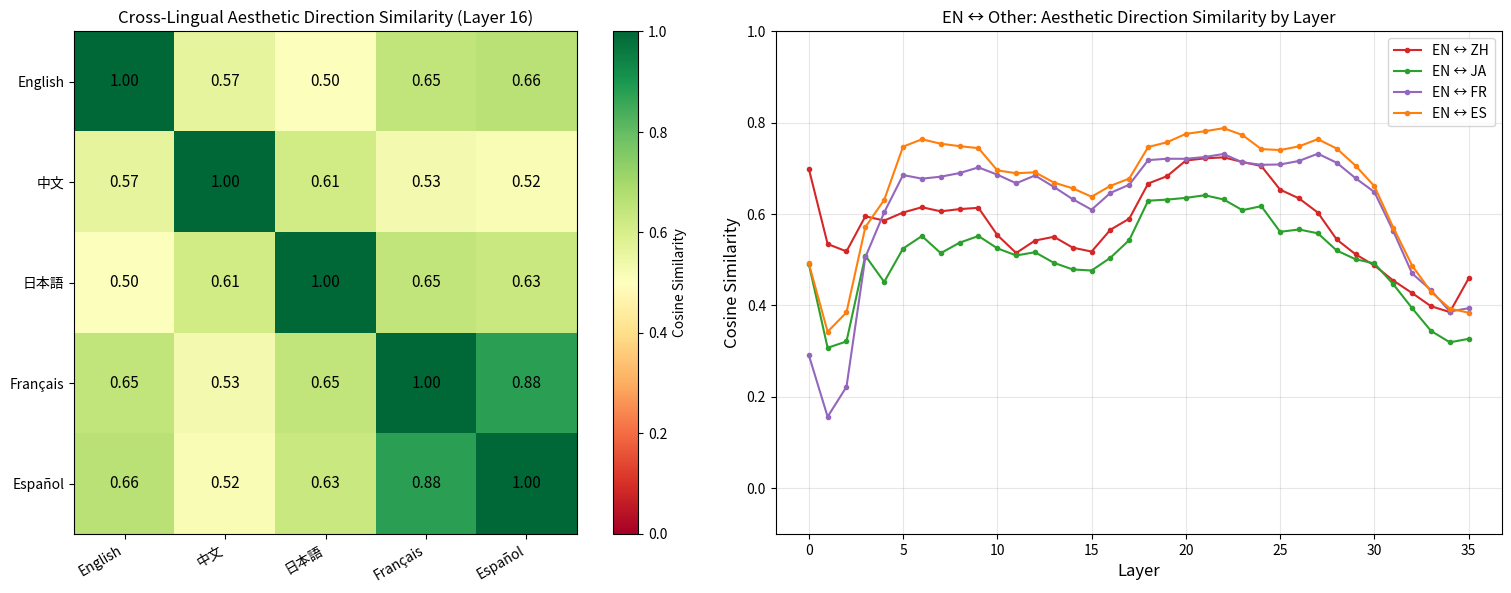

In [9]:
# --- Heatmap of cross-lingual similarity at best layer ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Similarity matrix heatmap
ax = axes[0]
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(LANGUAGES)))
ax.set_xticklabels([LANG_NAMES[l].split('(')[0].strip() for l in LANGUAGES], rotation=30, ha='right')
ax.set_yticks(range(len(LANGUAGES)))
ax.set_yticklabels([LANG_NAMES[l].split('(')[0].strip() for l in LANGUAGES])
ax.set_title(f'Cross-Lingual Aesthetic Direction Similarity (Layer {best_layer})', fontsize=12)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
# Annotate
for i in range(len(LANGUAGES)):
    for j in range(len(LANGUAGES)):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=11,
                color='white' if sim_matrix[i,j] < 0.4 else 'black')

# Similarity across layers for each language pair with English
ax = axes[1]
for lang in LANGUAGES[1:]:  # skip EN-EN
    sims = [cosine_sim(lang_directions[lang][l], lang_directions['EN'][l]) for l in range(N_LAYERS)]
    ax.plot(layers, sims, 'o-', color=LANG_COLORS[lang], label=f'EN ↔ {lang}', markersize=3)

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Cosine Similarity', fontsize=12)
ax.set_title('EN ↔ Other: Aesthetic Direction Similarity by Layer', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_lingual_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. PCA Visualization — Language vs. Aesthetics

Key question: In activation space, do sentences cluster **by language** or **by aesthetic quality**?

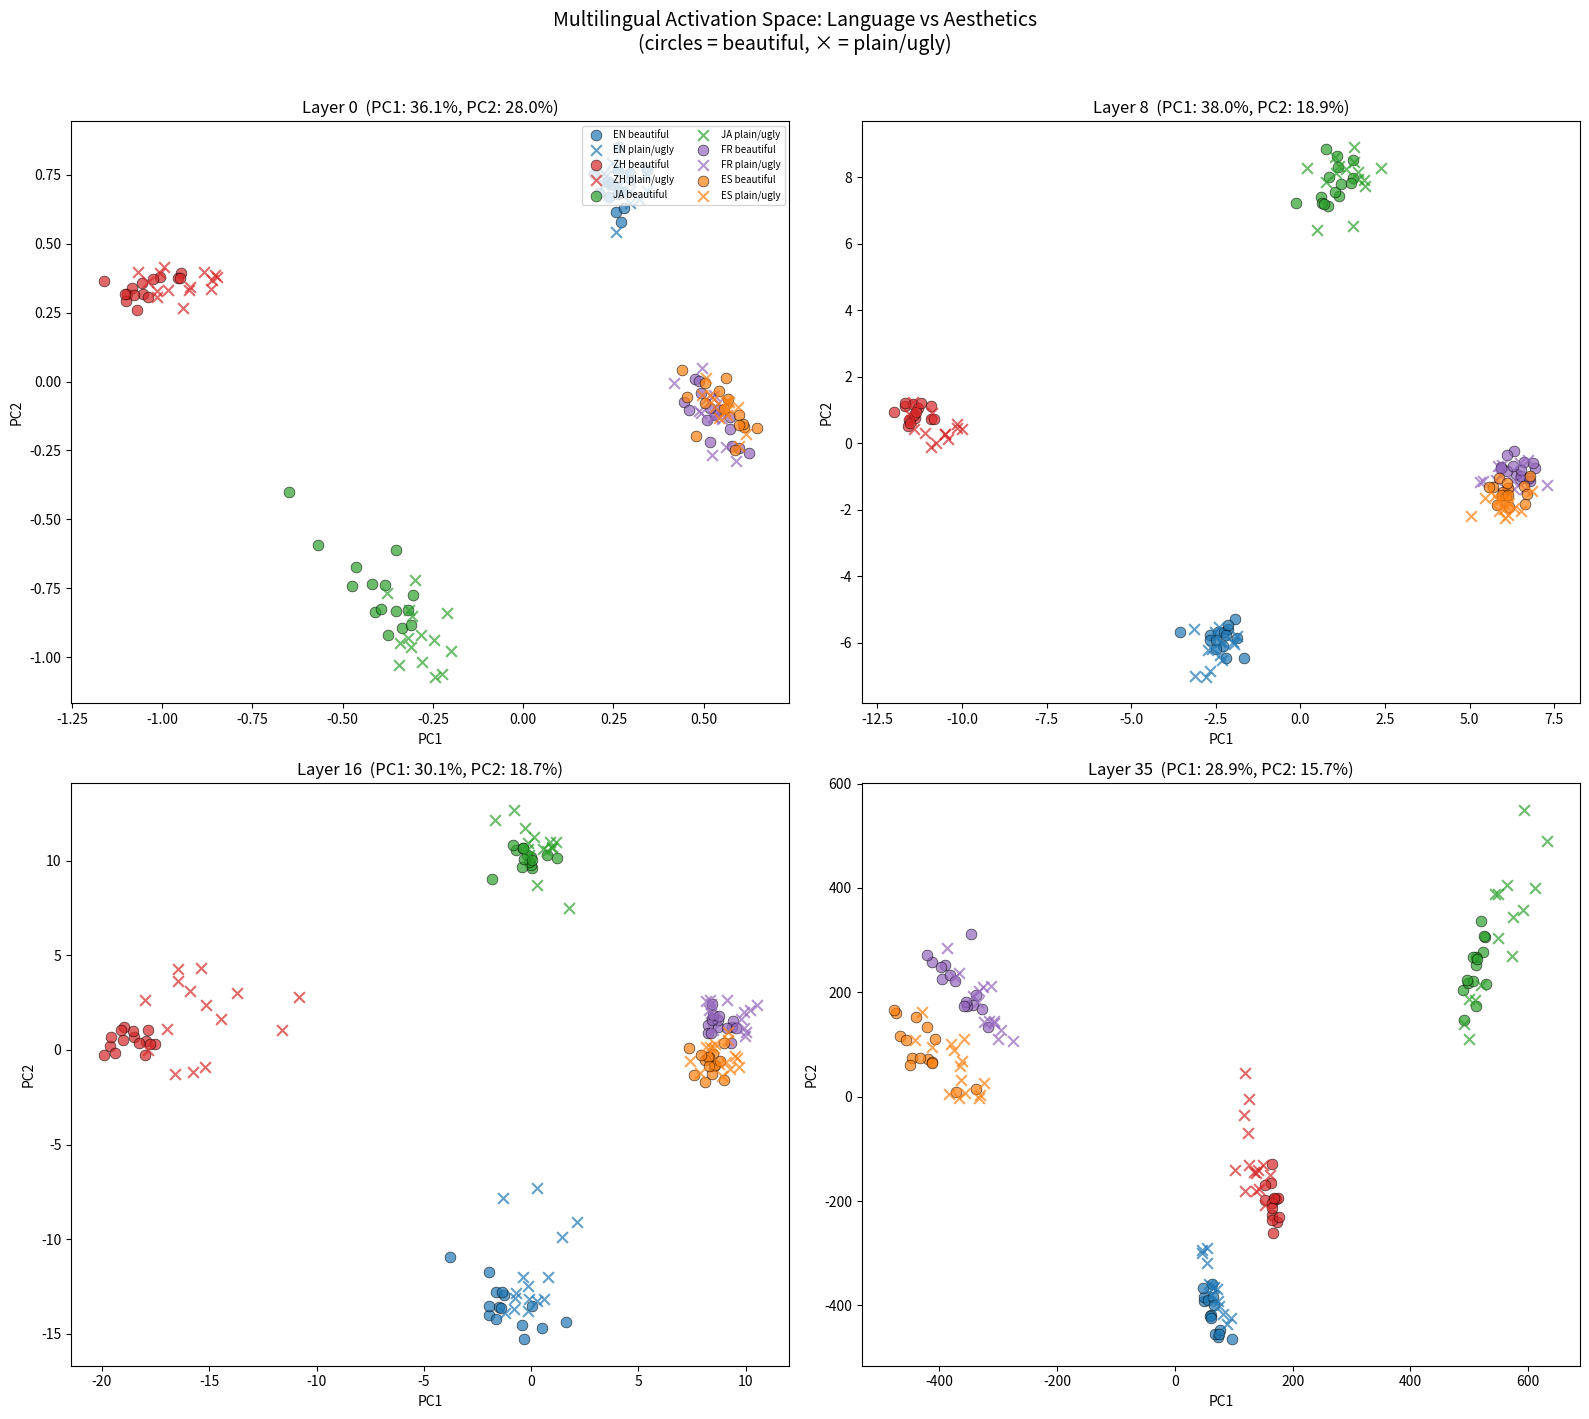

In [10]:
# PCA on all 150 sentences at the best layer
viz_layers = [0, best_layer // 2, best_layer, N_LAYERS - 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for idx, layer in enumerate(viz_layers):
    ax = axes[idx // 2, idx % 2]
    
    # Stack all languages
    X_all = np.vstack([activations[lang][:, layer, :] for lang in LANGUAGES])  # (150, 4096)
    lang_ids = np.concatenate([[lang]*N_PER_LANG for lang in LANGUAGES])
    beauty_ids = np.concatenate([labels[lang] for lang in LANGUAGES])  # 0/1
    
    pca = PCA(n_components=2)
    X_proj = pca.fit_transform(X_all)
    
    # Plot by language AND aesthetics (color = language, marker = aesthetic)
    for li, lang in enumerate(LANGUAGES):
        start = li * N_PER_LANG
        # Beautiful (circles)
        mask_b = np.arange(start, start + N_BEAUTIFUL)
        ax.scatter(X_proj[mask_b, 0], X_proj[mask_b, 1], c=LANG_COLORS[lang],
                   marker='o', s=60, alpha=0.7, edgecolors='black', linewidth=0.5,
                   label=f'{lang} beautiful' if idx == 0 else '')
        # Plain/ugly (crosses)
        mask_u = np.arange(start + N_BEAUTIFUL, start + N_PER_LANG)
        ax.scatter(X_proj[mask_u, 0], X_proj[mask_u, 1], c=LANG_COLORS[lang],
                   marker='x', s=60, alpha=0.7, linewidth=1.5,
                   label=f'{lang} plain/ugly' if idx == 0 else '')
    
    ax.set_title(f'Layer {layer}  (PC1: {pca.explained_variance_ratio_[0]:.1%}, PC2: {pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
    ax.set_xlabel(f'PC1')
    ax.set_ylabel(f'PC2')

axes[0, 0].legend(fontsize=7, ncol=2, loc='upper right')
plt.suptitle('Multilingual Activation Space: Language vs Aesthetics\n(circles = beautiful, × = plain/ugly)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_language_vs_aesthetics.png', dpi=150, bbox_inches='tight')
plt.show()

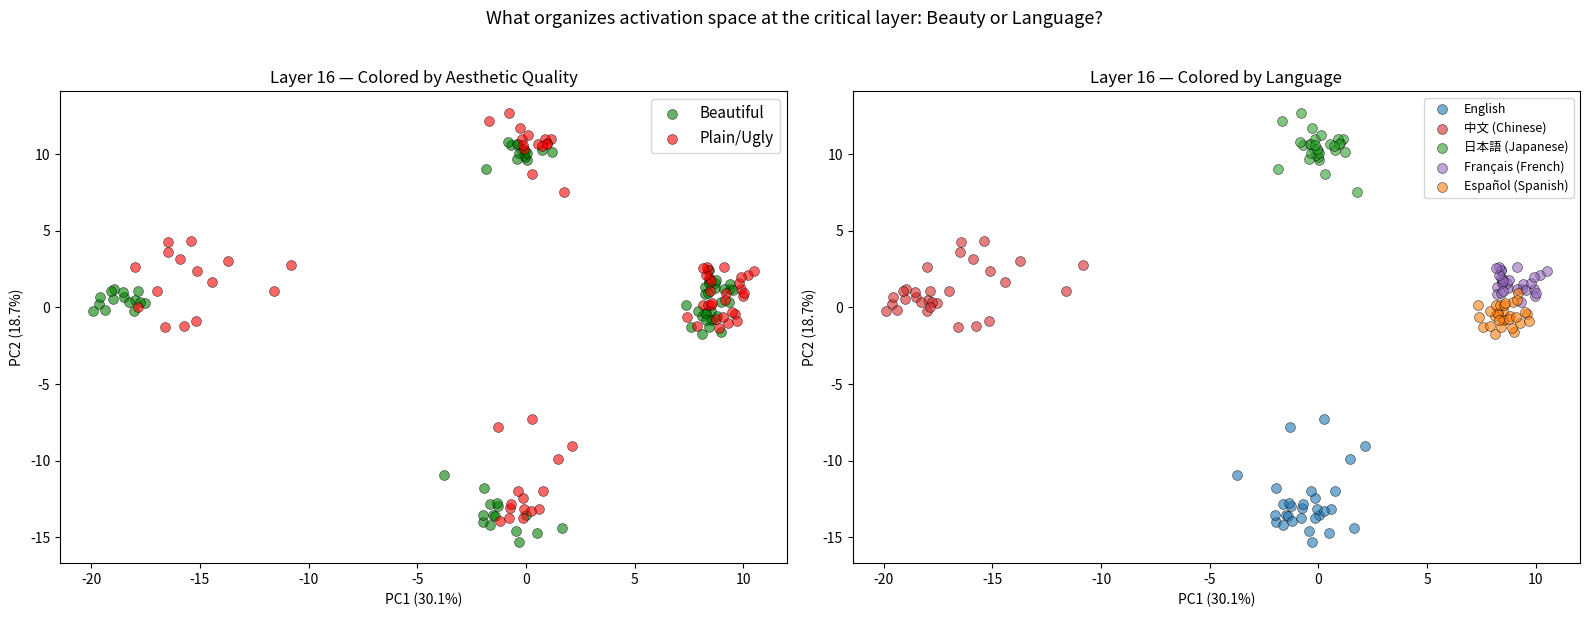

In [11]:
# --- Focused PCA at best layer: color by aesthetics only ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

layer = best_layer
X_all = np.vstack([activations[lang][:, layer, :] for lang in LANGUAGES])
pca = PCA(n_components=2)
X_proj = pca.fit_transform(X_all)
beauty_ids = np.concatenate([labels[lang] for lang in LANGUAGES])
lang_ids = np.concatenate([[i]*N_PER_LANG for i in range(len(LANGUAGES))])

# Left: color by aesthetics
ax = axes[0]
for aes, color, name in [(1, 'green', 'Beautiful'), (0, 'red', 'Plain/Ugly')]:
    mask = beauty_ids == aes
    ax.scatter(X_proj[mask, 0], X_proj[mask, 1], c=color, alpha=0.6, s=50,
               edgecolors='black', linewidth=0.5, label=name)
ax.set_title(f'Layer {layer} — Colored by Aesthetic Quality', fontsize=12)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(fontsize=11)

# Right: color by language
ax = axes[1]
for li, lang in enumerate(LANGUAGES):
    mask = lang_ids == li
    ax.scatter(X_proj[mask, 0], X_proj[mask, 1], c=LANG_COLORS[lang], alpha=0.6, s=50,
               edgecolors='black', linewidth=0.5, label=LANG_NAMES[lang])
ax.set_title(f'Layer {layer} — Colored by Language', fontsize=12)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(fontsize=9)

plt.suptitle('What organizes activation space at the critical layer: Beauty or Language?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_beauty_vs_language.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Cross-Lingual Probe Transfer

Train a linear probe on **English only**, test on each other language. This is the strongest test of universality — can an English-trained classifier read aesthetic quality from Chinese or Japanese activations?

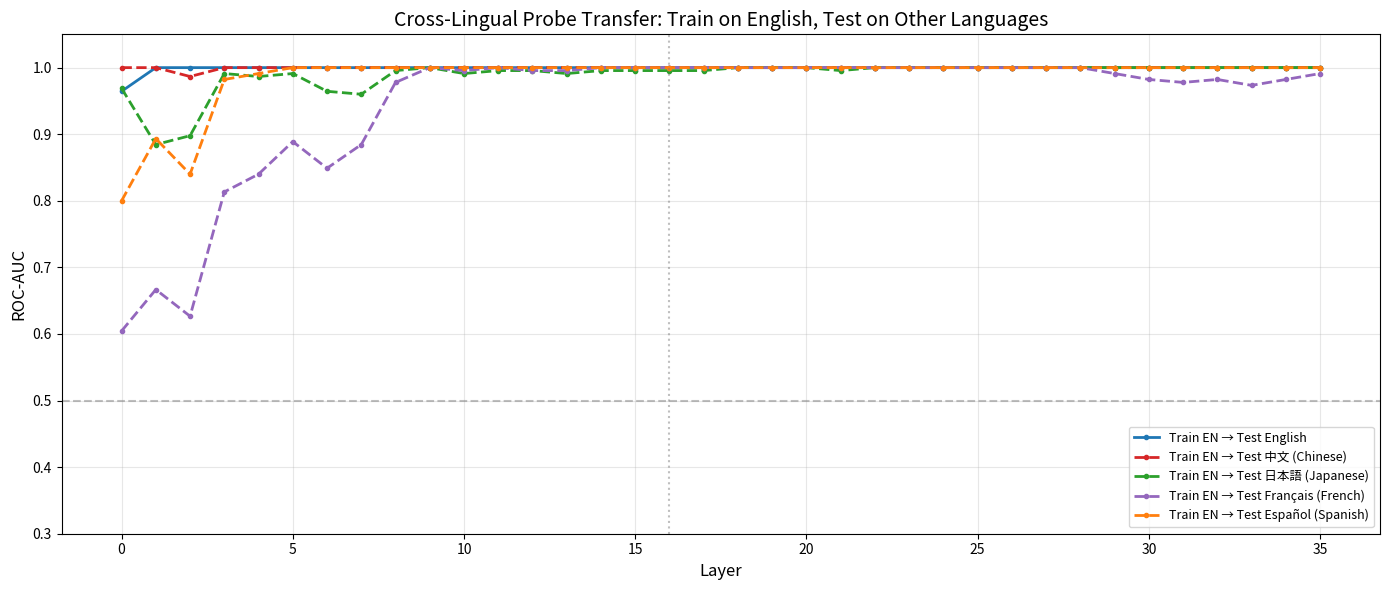


Cross-lingual probe transfer AUC at Layer 16:
  EN → EN (English        ): AUC = 1.000  ✓ Perfect
  EN → ZH (中文 (Chinese)   ): AUC = 1.000  ✓ Perfect
  EN → JA (日本語 (Japanese) ): AUC = 0.996  ✓ Excellent
  EN → FR (Français (French)): AUC = 1.000  ✓ Perfect
  EN → ES (Español (Spanish)): AUC = 1.000  ✓ Perfect


In [12]:
# Train on English, test on each other language at every layer
cross_probe_auc = {}  # target_lang -> (36,) AUC

for target_lang in LANGUAGES:
    aucs = []
    for layer in range(N_LAYERS):
        # Train on English
        X_train = activations['EN'][:, layer, :]
        y_train = labels['EN']
        
        # Test on target
        X_test = activations[target_lang][:, layer, :]
        y_test = labels[target_lang]
        
        clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)
        clf.fit(X_train, y_train)
        pred_proba = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, pred_proba)
        aucs.append(auc)
    cross_probe_auc[target_lang] = np.array(aucs)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
for lang in LANGUAGES:
    style = '-' if lang == 'EN' else '--'
    ax.plot(layers, cross_probe_auc[lang], f'o{style}', color=LANG_COLORS[lang],
            label=f'Train EN → Test {LANG_NAMES[lang]}', markersize=3, linewidth=2)

ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.axvline(best_layer, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('Cross-Lingual Probe Transfer: Train on English, Test on Other Languages', fontsize=14)
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(0.3, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_lingual_probe_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary at best layer
print(f'\nCross-lingual probe transfer AUC at Layer {best_layer}:')
for lang in LANGUAGES:
    auc = cross_probe_auc[lang][best_layer]
    status = '✓ Perfect' if auc >= 0.999 else ('✓ Excellent' if auc >= 0.95 else ('~ Good' if auc >= 0.85 else '✗ Weak'))
    print(f'  EN → {lang} ({LANG_NAMES[lang]:15s}): AUC = {auc:.3f}  {status}')

## 9. Bidirectional Transfer Matrix

Train on each language, test on every other. The full 5×5 transfer matrix reveals whether any languages are closer or more distant in aesthetic representation.

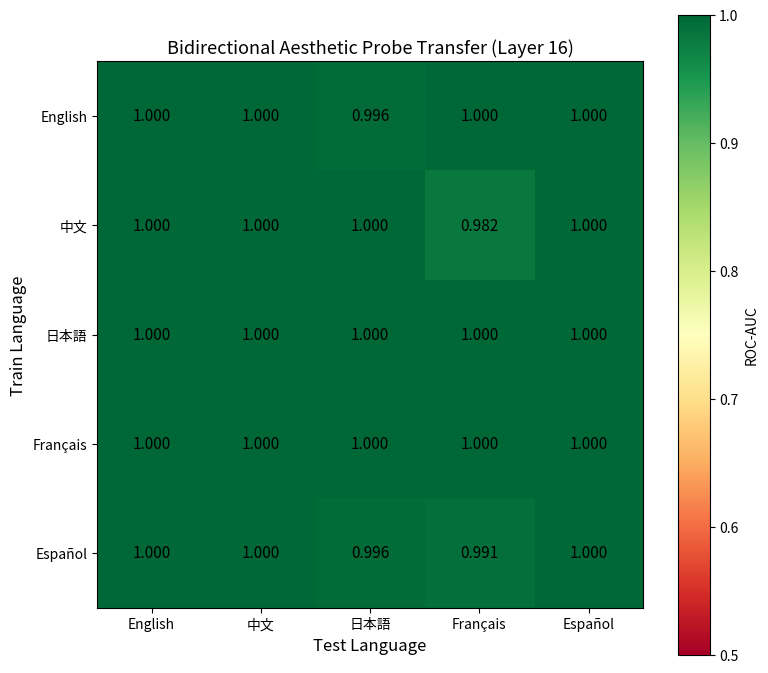

Off-diagonal (cross-lingual) AUC: mean=0.998, min=0.982, max=1.000
Diagonal (within-language) AUC: 1.000


In [13]:
# Full NxN transfer matrix at best_layer
layer = best_layer
transfer_matrix = np.zeros((len(LANGUAGES), len(LANGUAGES)))

for i, src in enumerate(LANGUAGES):
    for j, tgt in enumerate(LANGUAGES):
        X_train = activations[src][:, layer, :]
        y_train = labels[src]
        X_test = activations[tgt][:, layer, :]
        y_test = labels[tgt]
        
        clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)
        clf.fit(X_train, y_train)
        pred_proba = clf.predict_proba(X_test)[:, 1]
        transfer_matrix[i, j] = roc_auc_score(y_test, pred_proba)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(transfer_matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(LANGUAGES)))
ax.set_xticklabels([LANG_NAMES[l].split('(')[0].strip() for l in LANGUAGES])
ax.set_yticks(range(len(LANGUAGES)))
ax.set_yticklabels([LANG_NAMES[l].split('(')[0].strip() for l in LANGUAGES])
ax.set_xlabel('Test Language', fontsize=12)
ax.set_ylabel('Train Language', fontsize=12)
ax.set_title(f'Bidirectional Aesthetic Probe Transfer (Layer {layer})', fontsize=13)
plt.colorbar(im, ax=ax, label='ROC-AUC')

for i in range(len(LANGUAGES)):
    for j in range(len(LANGUAGES)):
        color = 'white' if transfer_matrix[i,j] < 0.65 else 'black'
        ax.text(j, i, f'{transfer_matrix[i,j]:.3f}', ha='center', va='center', fontsize=11, color=color)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bidirectional_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
off_diag = transfer_matrix[~np.eye(len(LANGUAGES), dtype=bool)]
print(f'Off-diagonal (cross-lingual) AUC: mean={off_diag.mean():.3f}, min={off_diag.min():.3f}, max={off_diag.max():.3f}')
print(f'Diagonal (within-language) AUC: {np.diag(transfer_matrix).mean():.3f}')

## 10. Aesthetic Direction Norm by Language

Compare how the aesthetic direction magnitude evolves through layers for each language.

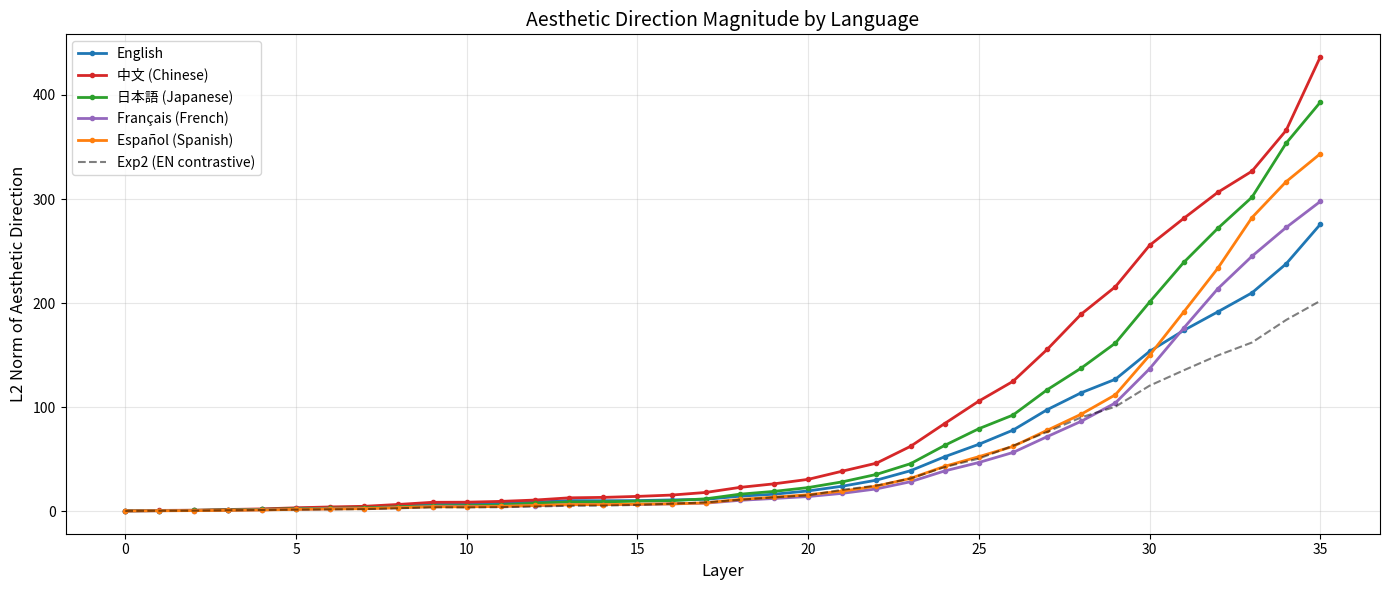

In [14]:
# Direction L2 norm across layers for each language
fig, ax = plt.subplots(figsize=(14, 6))

for lang in LANGUAGES:
    norms = np.linalg.norm(lang_directions[lang], axis=1)  # (36,)
    ax.plot(layers, norms, 'o-', color=LANG_COLORS[lang], label=LANG_NAMES[lang], markersize=3, linewidth=2)

# Also plot Exp2 direction norm
exp2_norms = np.linalg.norm(aesthetic_direction, axis=1)
ax.plot(layers, exp2_norms, 'k--', linewidth=1.5, alpha=0.5, label='Exp2 (EN contrastive)')

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('L2 Norm of Aesthetic Direction', fontsize=12)
ax.set_title('Aesthetic Direction Magnitude by Language', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'direction_norm_by_language.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Cluster Analysis — Beauty vs. Language

Quantify whether activations cluster more by **aesthetic quality** or by **language** using silhouette scores at each layer.

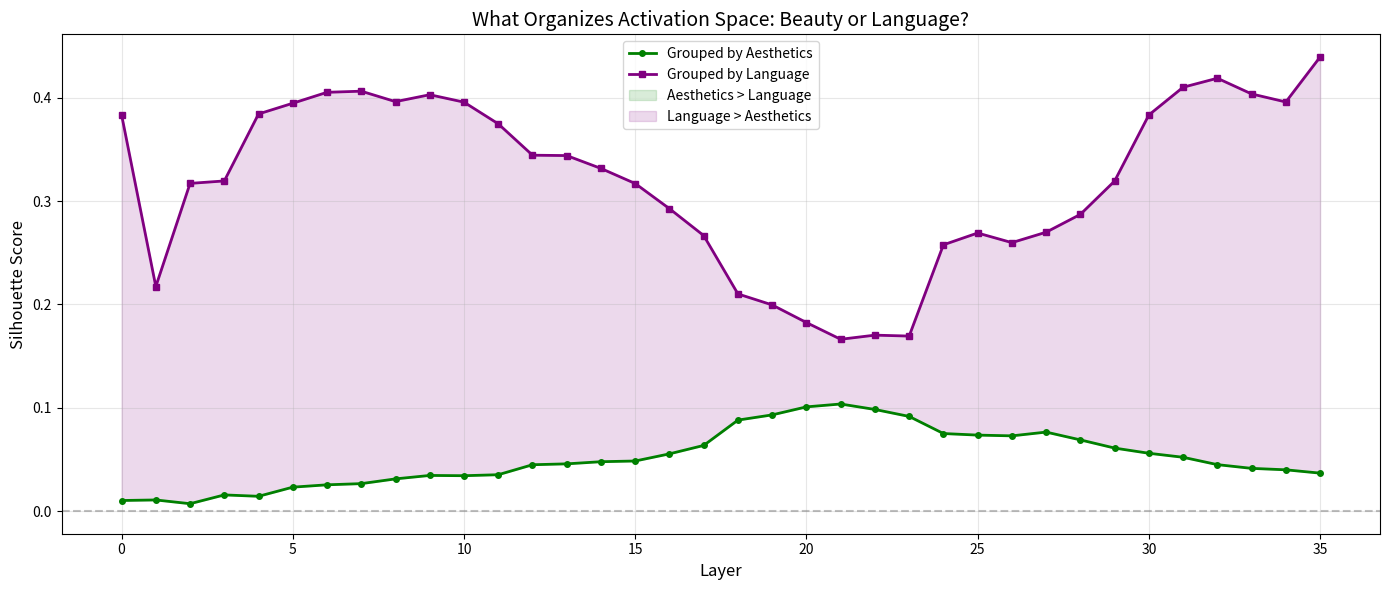

Language always dominates aesthetics in silhouette score.

At Layer 16:
  Silhouette (beauty):   0.055
  Silhouette (language): 0.293
  Ratio: 0.19×


In [15]:
from sklearn.metrics import silhouette_score

sil_beauty = []  # silhouette score when grouping by beauty label
sil_lang = []    # silhouette score when grouping by language

beauty_labels_all = np.concatenate([labels[lang] for lang in LANGUAGES])
lang_labels_all = np.concatenate([[i]*N_PER_LANG for i in range(len(LANGUAGES))])

for layer in range(N_LAYERS):
    X = np.vstack([activations[lang][:, layer, :] for lang in LANGUAGES])
    sil_beauty.append(silhouette_score(X, beauty_labels_all))
    sil_lang.append(silhouette_score(X, lang_labels_all))

sil_beauty = np.array(sil_beauty)
sil_lang = np.array(sil_lang)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(layers, sil_beauty, 'o-', color='green', label='Grouped by Aesthetics', linewidth=2, markersize=4)
ax.plot(layers, sil_lang, 's-', color='purple', label='Grouped by Language', linewidth=2, markersize=4)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.fill_between(layers, sil_beauty, sil_lang, where=sil_beauty > sil_lang,
                alpha=0.15, color='green', label='Aesthetics > Language')
ax.fill_between(layers, sil_beauty, sil_lang, where=sil_lang > sil_beauty,
                alpha=0.15, color='purple', label='Language > Aesthetics')

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('What Organizes Activation Space: Beauty or Language?', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'silhouette_beauty_vs_language.png', dpi=150, bbox_inches='tight')
plt.show()

# Report
crossover = np.where(sil_beauty > sil_lang)[0]
if len(crossover) > 0:
    print(f'Aesthetics dominates language from layer {crossover[0]}')
else:
    print('Language always dominates aesthetics in silhouette score.')

print(f'\nAt Layer {best_layer}:')
print(f'  Silhouette (beauty):   {sil_beauty[best_layer]:.3f}')
print(f'  Silhouette (language): {sil_lang[best_layer]:.3f}')
print(f'  Ratio: {sil_beauty[best_layer] / (sil_lang[best_layer] + 1e-10):.2f}×')

## 12. Summary & Save Results

In [16]:
# Save all analysis results
np.savez_compressed(OUTPUT_DIR / 'cross_lingual_results.npz',
    transfer_auc=np.array([transfer_auc[l] for l in LANGUAGES]),   # (5, 36)
    cross_probe_auc=np.array([cross_probe_auc[l] for l in LANGUAGES]),  # (5, 36)
    transfer_matrix=transfer_matrix,   # (5, 5)
    sim_matrix=sim_matrix,             # (5, 5)
    sil_beauty=sil_beauty,
    sil_lang=sil_lang,
    languages=np.array(LANGUAGES),
    best_layer=best_layer,
)

print('=' * 65)
print('EXPERIMENT 4 SUMMARY: Cross-Lingual Aesthetic Universality')
print('=' * 65)
print(f'Model: Qwen3-8B Q4_K_M ({N_LAYERS} layers, {N_EMBD} hidden dim)')
print(f'Languages: {", ".join(LANG_NAMES[l] for l in LANGUAGES)}')
print(f'Dataset: {N_PER_LANG} sentences/language × {len(LANGUAGES)} languages = {N_TOTAL} total')

print(f'\n--- Zero-Shot Transfer (Exp2 EN direction → all languages) ---')
for lang in LANGUAGES:
    auc = transfer_auc[lang][best_layer]
    print(f'  {lang}: AUC = {auc:.3f} at Layer {best_layer}')

print(f'\n--- Cross-Lingual Probe Transfer (Train EN → Test X, Layer {best_layer}) ---')
for lang in LANGUAGES:
    auc = cross_probe_auc[lang][best_layer]
    print(f'  EN → {lang}: AUC = {auc:.3f}')

print(f'\n--- Aesthetic Direction Cosine Similarity (Layer {best_layer}) ---')
off_diag = sim_matrix[~np.eye(len(LANGUAGES), dtype=bool)]
print(f'  Mean pairwise: {off_diag.mean():.3f} (min={off_diag.min():.3f}, max={off_diag.max():.3f})')

print(f'\n--- Silhouette Analysis (Layer {best_layer}) ---')
print(f'  Beauty grouping:   {sil_beauty[best_layer]:.3f}')
print(f'  Language grouping:  {sil_lang[best_layer]:.3f}')
dominant = 'AESTHETICS' if sil_beauty[best_layer] > sil_lang[best_layer] else 'LANGUAGE'
print(f'  Dominant axis: {dominant}')

print(f'\n--- Bidirectional Transfer (Layer {best_layer}) ---')
off_diag_tm = transfer_matrix[~np.eye(len(LANGUAGES), dtype=bool)]
print(f'  Mean off-diagonal AUC: {off_diag_tm.mean():.3f}')
print(f'  Min cross-transfer: {off_diag_tm.min():.3f}')

print(f'\nResults saved to: {OUTPUT_DIR}')
print('=' * 65)

EXPERIMENT 4 SUMMARY: Cross-Lingual Aesthetic Universality
Model: Qwen3-8B Q4_K_M (36 layers, 4096 hidden dim)
Languages: English, 中文 (Chinese), 日本語 (Japanese), Français (French), Español (Spanish)
Dataset: 30 sentences/language × 5 languages = 150 total

--- Zero-Shot Transfer (Exp2 EN direction → all languages) ---
  EN: AUC = 1.000 at Layer 16
  ZH: AUC = 1.000 at Layer 16
  JA: AUC = 1.000 at Layer 16
  FR: AUC = 1.000 at Layer 16
  ES: AUC = 1.000 at Layer 16

--- Cross-Lingual Probe Transfer (Train EN → Test X, Layer 16) ---
  EN → EN: AUC = 1.000
  EN → ZH: AUC = 1.000
  EN → JA: AUC = 0.996
  EN → FR: AUC = 1.000
  EN → ES: AUC = 1.000

--- Aesthetic Direction Cosine Similarity (Layer 16) ---
  Mean pairwise: 0.619 (min=0.505, max=0.876)

--- Silhouette Analysis (Layer 16) ---
  Beauty grouping:   0.055
  Language grouping:  0.293
  Dominant axis: LANGUAGE

--- Bidirectional Transfer (Layer 16) ---
  Mean off-diagonal AUC: 0.998
  Min cross-transfer: 0.982

Results saved to: /w

In [17]:
# Cleanup
engine.reset()
print('Engine reset. Ready for next experiment.')

Engine reset. Ready for next experiment.
